In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
#导入多元正态分布,用于多维数据
#这个库建立在numpy之上,具有更高级的功能 这里导入统计学模块
from scipy.stats import multivariate_normal 

In [5]:
#创建二维数组
np.random.seed(0)
mean = [4,3]
cov = [[1,0.5],
       [0.5,1]]
data = np.random.multivariate_normal(mean,cov,300) #这是numpy自带的,还没用到scipy
cov_used = np.array(cov)

In [7]:
#马氏距离自定义函数
def mahalanobis_distance(x,mean,cov_inv):
    delta = x - mean
    return np.sqrt(np.dot(np.dot(delta,cov_inv),delta.T))

In [9]:
#网络数据
x,y = np.meshgrid(
    np.linspace(0,10,100),
    np.linspace(0,10,100),)
#ravel展开为1D数组
pos = np.c_[x.ravel(),y.ravel()]

In [17]:
#计算马氏距离
cov_inv = np.linalg.inv(cov_used)

Mahal_dd = np.diag((pos - mean) @ cov_inv @ (pos - mean).T)
Mahal_dd = np.sqrt(Mahal_dd)
Mahal_dd = np.reshape(Mahal_dd,x.shape)

[]

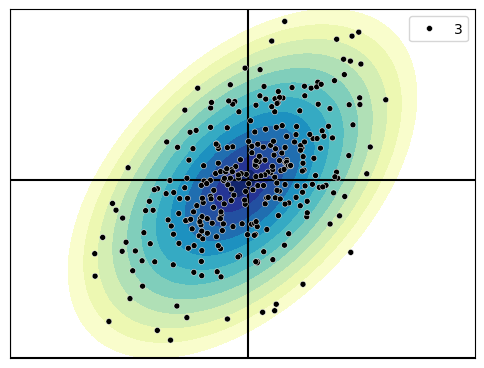

In [63]:
fig,ax = plt.subplots(figsize = (6,6))

#levels配置等高线分级,绘图将根据其中的间隔点的马氏距离绘制控制范围在(0,3)
plt.contourf(x,y,Mahal_dd,cmap = 'YlGnBu_r',levels = np.linspace(0,3,13))

#绘制数据散点
ax = sns.scatterplot(x = data[:,0],y = data[:,1],
                     marker = 'o',zorder = 1e3,
                     color = 'k',size =3)

ax.axvline(x = 0,c = 'k')
ax.axhline(y = 0,c = 'k')
ax.axvline(x = data[:,0].mean(),c = 'k')
ax.axhline(y = data[:,1].mean(),c = 'k')
#自动调整坐标范围并让显示的单位长度相等 set_aspect只能保证显示的单位长度相等
ax.axis('scaled')
#更底层的调整范围,近似lim但是需要写明参数
ax.set_xbound(lower = 0,upper = 8)
ax.set_ybound(lower = 0,upper = 6)
ax.xaxis.set_ticks([])
ax.yaxis.set_ticks([])

In [65]:
#中心化数据

In [67]:
Xc = data - mean

[]

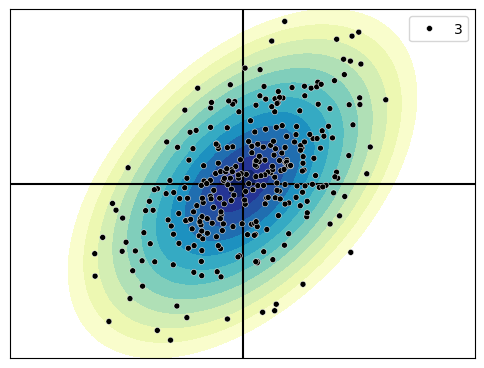

In [81]:
fig,ax = plt.subplots(figsize = (6,6))
plt.contourf(x - mean[0],y - mean[1],Mahal_dd,cmap = 'YlGnBu_r',levels = np.linspace(0,3,13))

ax = sns.scatterplot(x = Xc[:,0],y = Xc[:,1],
                     marker = 'o',zorder = 1e3,
                     color = 'k',size = 3)
ax.axvline(x = 0,c = 'k')
ax.axhline(y = 0,c = 'k')
ax.axvline(x = data[:,0].mean(),c = 'k')
ax.axhline(y = data[:,1].mean(),c = 'k')
ax.axis('scaled')
ax.set_xbound(lower = -4,upper = 4)
ax.set_ybound(lower = -3,upper = 3)
ax.xaxis.set_ticks([])
ax.yaxis.set_ticks([])

In [83]:
eig_values,V = np.linalg.eig(cov)

In [85]:
eig_values

array([1.5, 0.5])

In [87]:
V

array([[ 0.70710678, -0.70710678],
       [ 0.70710678,  0.70710678]])

In [89]:
Lambda = np.diag(eig_values)
Lambda

array([[1.5, 0. ],
       [0. , 0.5]])

In [107]:
theta = np.pi/4
v1 = np.array([[np.cos(theta)],
               [np.sin(theta)]])
#变成右乘了,所以和列向量左乘是相反的,每个点都是行向量了
#整个转置左乘变成右乘,投影矩阵也要跟着转置,相应的构成投影矩阵的投影向量也要转置
T1 = v1@v1.T
z1_1D = Xc@v1
z1_2D = Xc@T1

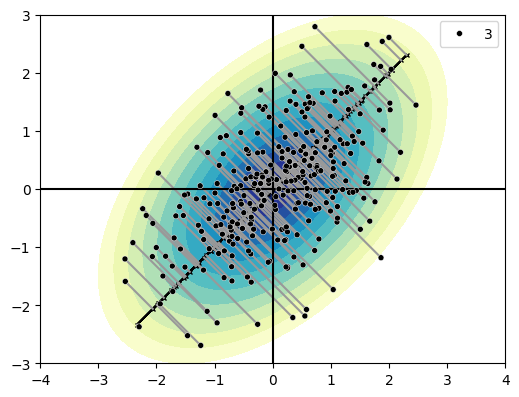

In [121]:
fig,ax = plt.subplots(figsize = (6,6))

plt.contourf(x - mean[0],y - mean[1],Mahal_dd,cmap = 'YlGnBu_r',levels = np.linspace(0,3,13))

ax = sns.scatterplot(x = Xc[:,0],y = Xc[:,1],
                     marker = 'o',zorder = 1e3,
                     color = 'k',size = 3)

plt.plot(z1_2D[:,0],z1_2D[:,1],marker = 'x',markersize = 3,color = 'k')

plt.plot(([i for (i,j) in z1_2D],[i for (i,j) in Xc]),
         ([j for (i,j) in z1_2D],[j for (i,j) in Xc]),c = [0.6,0.6,0.6])

ax.axvline(x = 0,c = 'k')
ax.axhline(y = 0,c = 'k')
ax.axvline(x = data[:,0].mean(),c = 'k')
ax.axhline(y = data[:,1].mean(),c = 'k')
ax.axis('scaled')
ax.set_xbound(lower = -4,upper = 4)
ax.set_ybound(lower = -3,upper = 3)
ax.xaxis.set_ticks = ([])
ax.yaxis.set_ticks = ([])

In [123]:
theta = -np.pi/4
v2 = np.array([[np.cos(theta)],
               [np.sin(theta)]])
T2 = v2@v2.T

z2_1D = Xc@v2
z2_2D = Xc@T2

[]

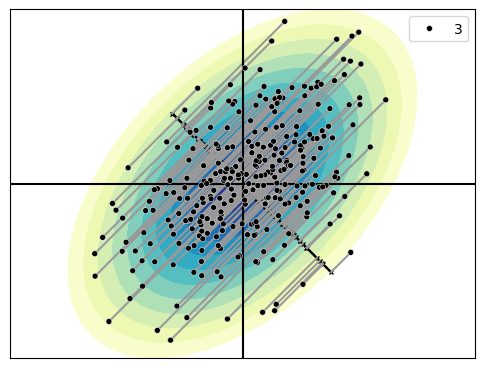

In [133]:
fig,ax = plt.subplots(figsize = (6,6))

plt.contourf(x - mean[0],y - mean[1],Mahal_dd,cmap = 'YlGnBu_r',levels = np.linspace(0,3,13))

ax = sns.scatterplot(x = Xc[:,0],y = Xc[:,1],
                     marker = 'o',zorder = 1e3,
                     color = 'k',size = 3)
#plt.plot默认为散点图,如果参数有linestyle将会变成连线图
plt.plot(z2_2D[:,0],z2_2D[:,1],marker = 'x',markersize = 3,color = 'k')

plt.plot(([i for (i,j) in z2_2D],[i for (i,j) in Xc]),
         ([j for (i,j) in z2_2D],[j for (i,j) in Xc]),c = [0.6,0.6,0.6])

ax.axvline(x = 0,c = 'k')
ax.axhline(y = 0,c = 'k')
ax.axvline(x = data[:,0].mean(),c = 'k')
ax.axhline(y = data[:,0].mean(),c = 'k')
ax.axis('scaled')
ax.set_xbound(lower = -4,upper = 4)
ax.set_ybound(lower = -3,upper = 3)
ax.xaxis.set_ticks([])
ax.yaxis.set_ticks([])